       year   max   min  precipitation daytime
51545  2016  27.6  23.5            2.0    雨時々曇
51910  2017  33.4  26.0            0.0   晴後時々曇
52275  2018  33.8  25.5            0.0      薄曇
52640  2019  27.3  20.0            0.5    曇一時雨
53006  2020  25.2  18.7            6.0    曇時々雨
53371  2021  29.0  23.4            0.0  曇、雷を伴う
53736  2022  25.2  22.6           53.0    雨時々曇
54101  2023  30.3  24.2            0.0    曇時々雨
54467  2024  31.3  22.5            0.0  薄曇後一時雨
54832  2025  32.3  22.2            0.0    晴時々曇
avg_max : 28.398675496688746
avg_min : 21.70264900662252


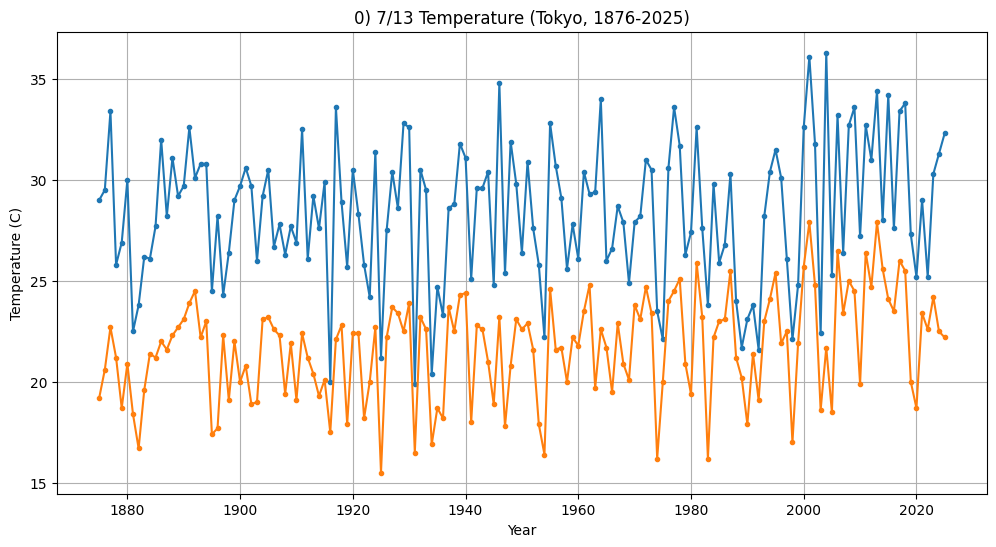

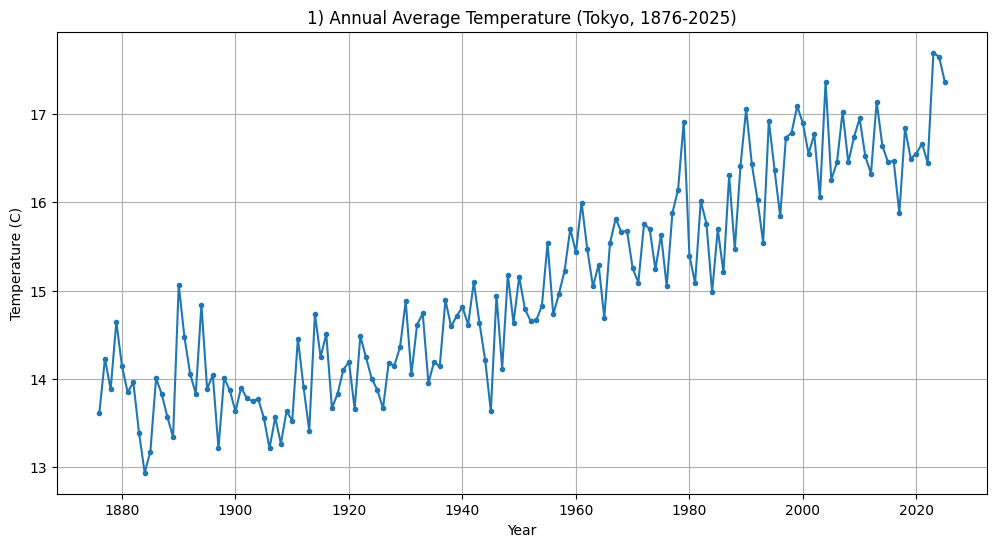

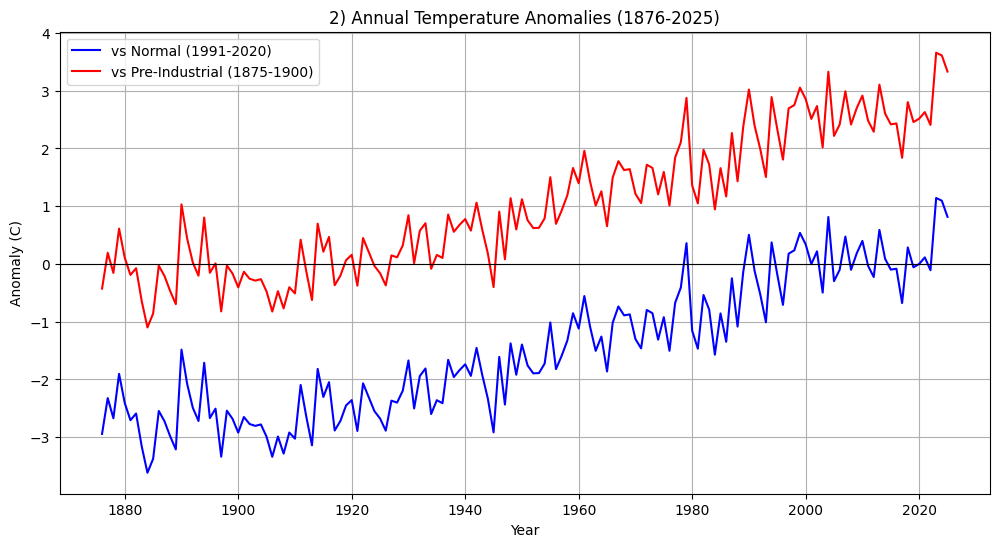

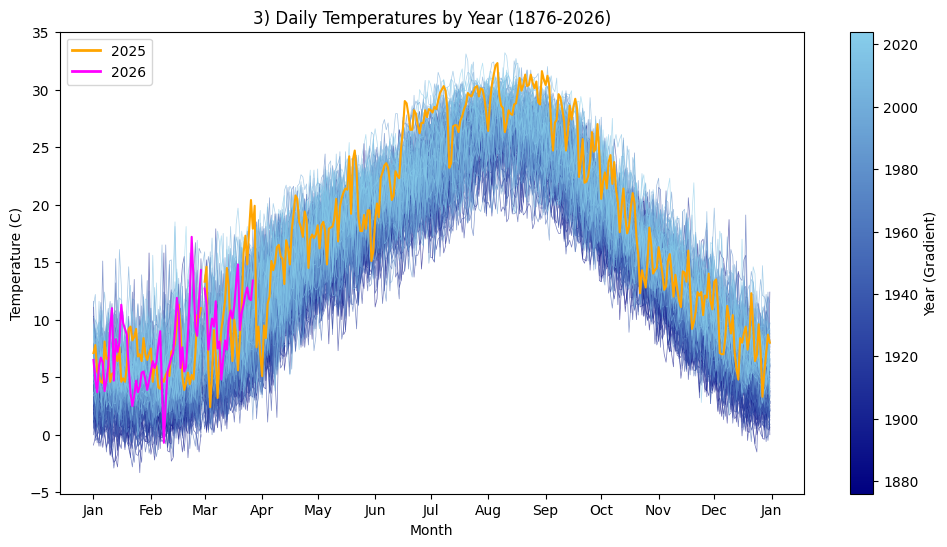

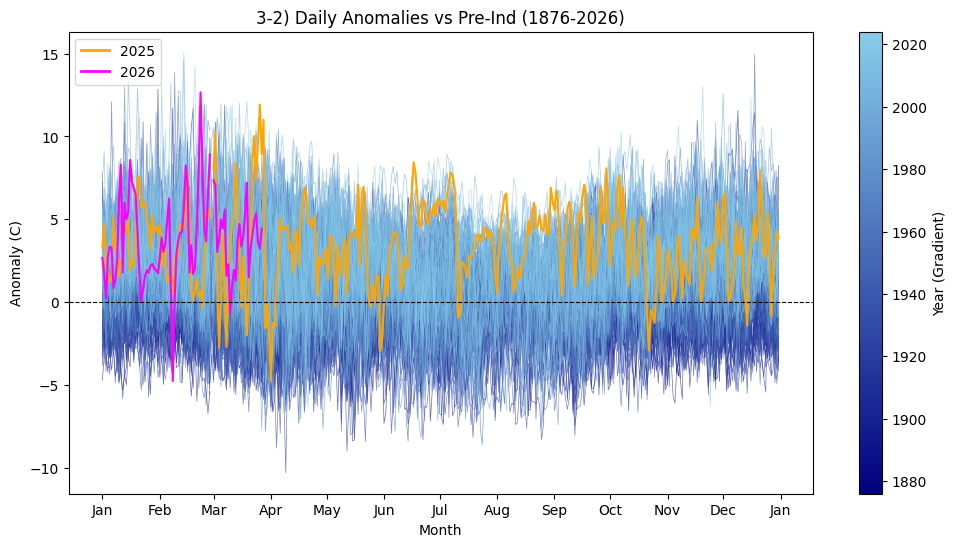

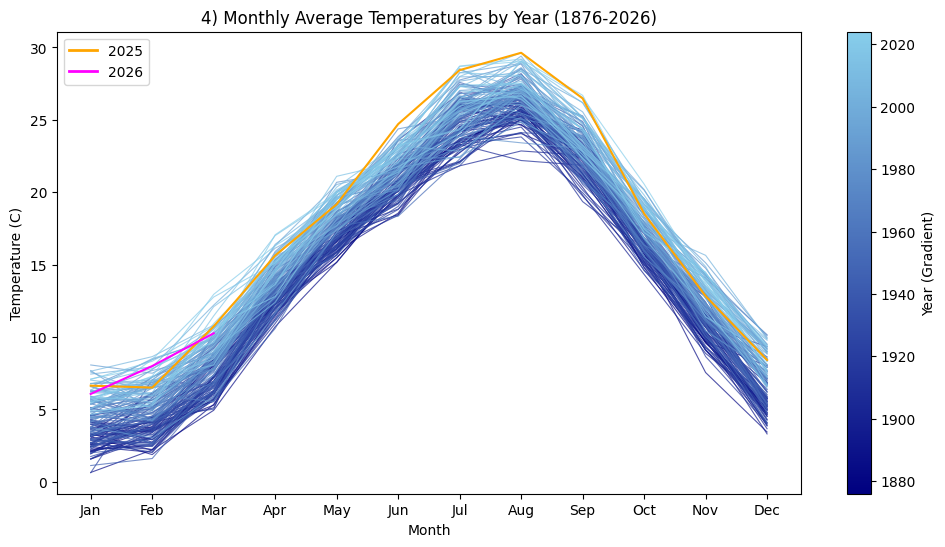

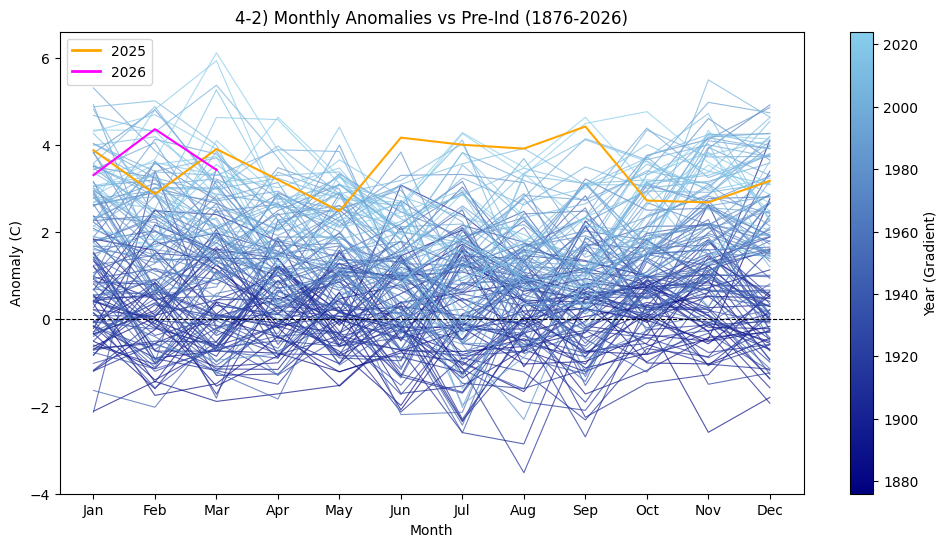

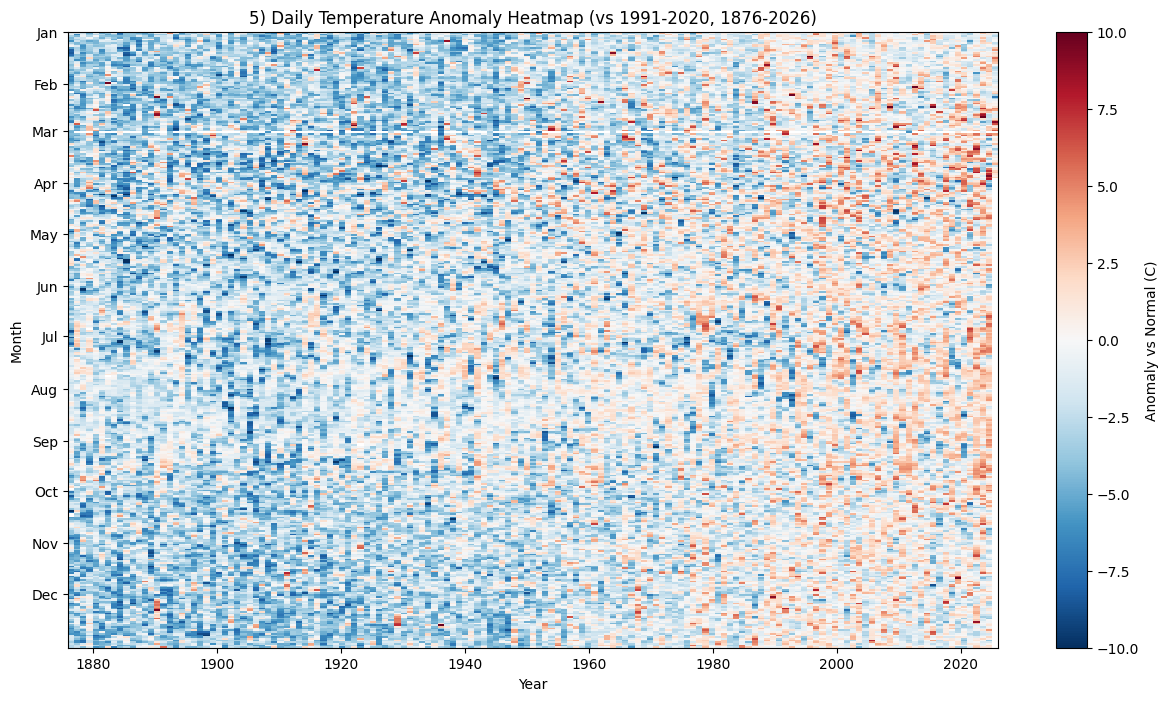

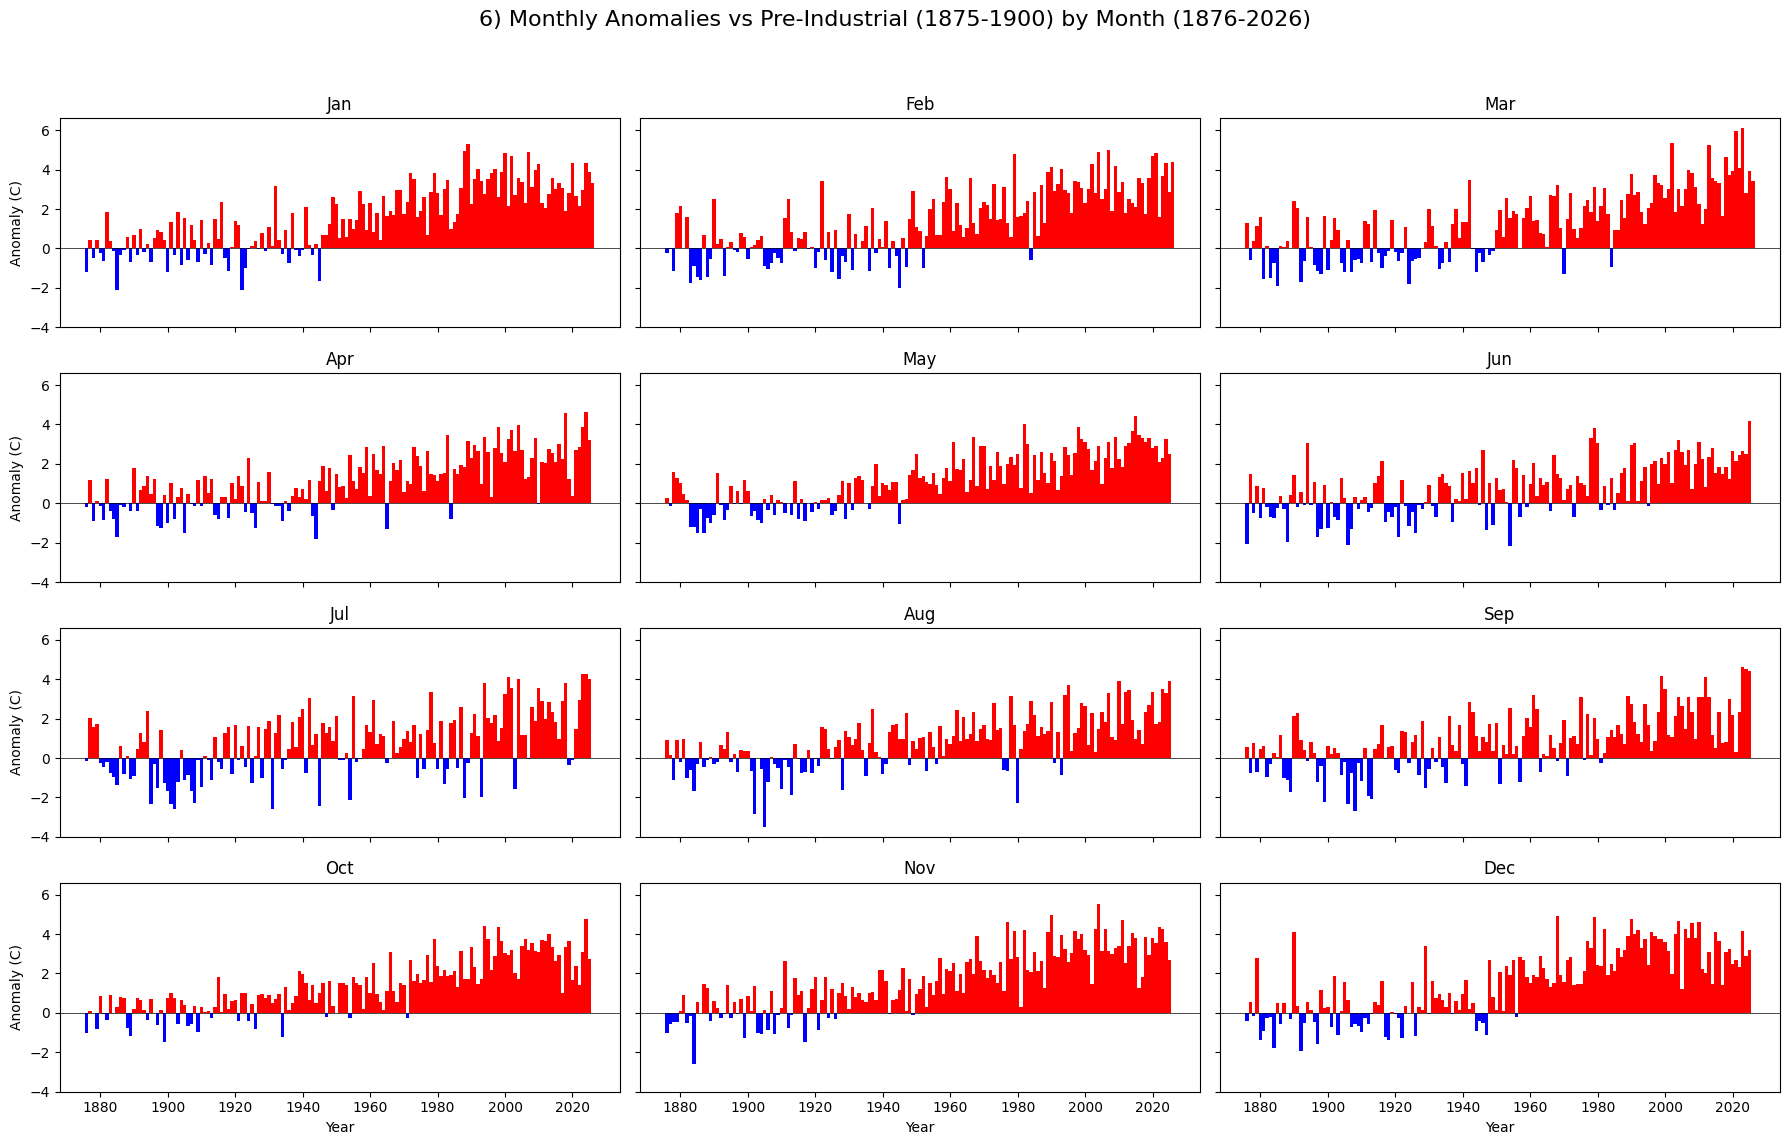

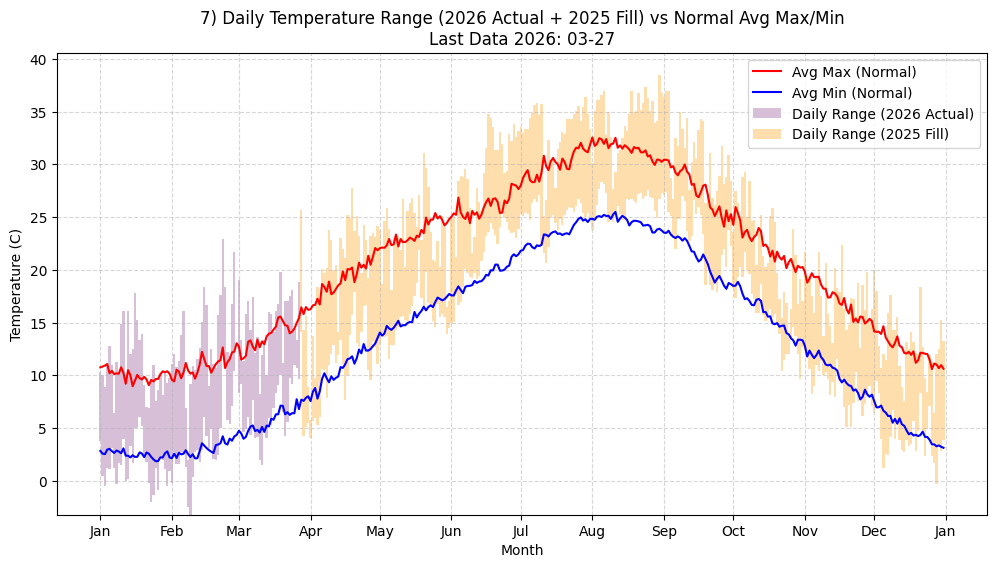

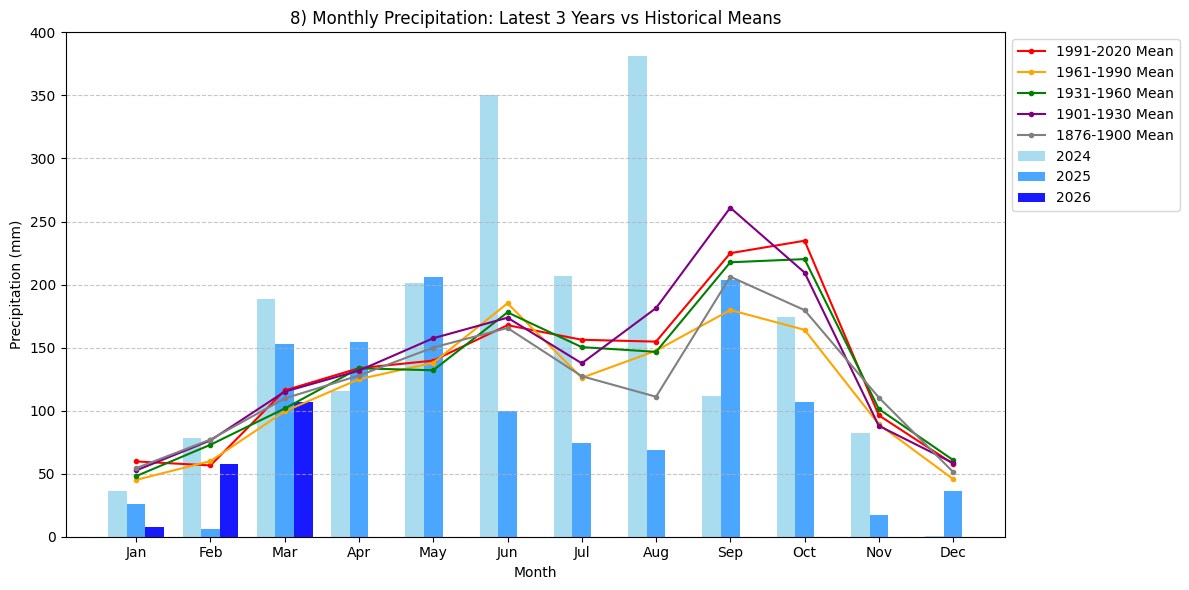

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
import numpy as np

# グラフのスタイル設定
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# データの読み込み
file_path = './気象データ/Japan/東京/tokyo.csv'
try:
    df = pd.read_csv(file_path) #, encoding='shift_jis')
except UnicodeDecodeError:
    df = pd.read_csv(file_path, encoding='cp932', encoding_errors='replace')

# --- 1. データの前処理 ---
def clean_data(df):
    cols = ['year', 'month', 'date', 'average', 'max', 'min', 'precipitation']
    for col in cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # 必須列(日付)が欠損している行を削除
    df = df.dropna(subset=['year', 'month', 'date'])

    df['year'] = df['year'].astype(int)
    df['month'] = df['month'].astype(int)
    df['date'] = df['date'].astype(int)
    df['day2'] = df['day']
    df['day'] = df['date']
    df['datetime'] = pd.to_datetime(df[['year', 'month', 'day']], errors='coerce')
    df = df.dropna(subset=['datetime'])

    df['md'] = df['month'].astype(str).str.zfill(2) + '-' + df['day'].astype(str).str.zfill(2)
    return df

df_clean = clean_data(df.copy())

# --- 2. 基準値の計算 (気温) ---
# 産業革命時基準 (1875-1900)
mask_preind = (df_clean['year'] >= 1875) & (df_clean['year'] <= 1900)
base_pre_annual = df_clean[mask_preind].groupby('year')['average'].mean().mean()
base_pre_monthly = df_clean[mask_preind].groupby('month')['average'].mean()
base_pre_daily = df_clean[mask_preind].groupby('md')['average'].mean()

# 平年基準 (1991-2020)
mask_normal = (df_clean['year'] >= 1991) & (df_clean['year'] <= 2020)
base_norm_annual = df_clean[mask_normal].groupby('year')['average'].mean().mean()
base_norm_daily = df_clean[mask_normal].groupby('md')['average'].mean()

# 平年値（最高・最低気温） for Graph 7
df_normal = df_clean[mask_normal]
norm_daily_stats = df_normal.groupby('md').agg({
    'max': 'mean',
    'min': 'mean'
})


#print(df_clean)


# 7/13（最高・最低気温）
the_data = df_clean[(df_clean['month'] == 7) & (df_clean['date'] == 13)]

# --- 3. 偏差の計算 (気温) ---
annual_data = df_clean.groupby('year')['average'].mean().reset_index()
annual_data['anomaly_norm'] = annual_data['average'] - base_norm_annual
annual_data['anomaly_preind'] = annual_data['average'] - base_pre_annual

df_clean['base_norm_d'] = df_clean['md'].map(base_norm_daily)
df_clean['base_pre_d'] = df_clean['md'].map(base_pre_daily)
df_clean['anomaly_norm'] = df_clean['average'] - df_clean['base_norm_d']
df_clean['anomaly_preind'] = df_clean['average'] - df_clean['base_pre_d']

monthly_data = df_clean.groupby(['year', 'month'])['average'].mean().reset_index()
monthly_data['datetime'] = pd.to_datetime(monthly_data[['year', 'month']].assign(day=1))
monthly_data['base_pre_m'] = monthly_data['month'].map(base_pre_monthly)
monthly_data['anomaly_preind'] = monthly_data['average'] - monthly_data['base_pre_m']

# 描画用データのフィルタリング（1876年以降）
start_year = 1876
annual_plot = annual_data[annual_data['year'] >= start_year].copy()
daily_plot = df_clean[df_clean['year'] >= start_year].copy()
monthly_plot = monthly_data[monthly_data['year'] >= start_year].copy()

# --- 年代の自動判定 (最新年など) ---
max_year_in_data = df_clean['year'].max()
prev_year = max_year_in_data - 1
prev_year_2 = max_year_in_data - 2
gradient_end_year = prev_year - 1

# --- 色設定用 ---
grad_years = np.arange(start_year, gradient_end_year + 1)
cmap_blue = mcolors.LinearSegmentedColormap.from_list("custom_blue", ["navy", "skyblue"])
norm_blue = plt.Normalize(grad_years.min(), grad_years.max())

def get_color(year):
    if year == max_year_in_data:
        return 'magenta'
    elif year == prev_year:
        return 'orange'
    elif year <= gradient_end_year:
        return cmap_blue(norm_blue(year))
    else:
        return 'grey'

sm = plt.cm.ScalarMappable(cmap=cmap_blue, norm=norm_blue)
sm.set_array([])
handles = [plt.Line2D([0], [0], color='orange', lw=2, label=str(prev_year)),
           plt.Line2D([0], [0], color='magenta', lw=2, label=str(max_year_in_data))]

# --- 8) 降水量のデータ準備 ---
# 月ごとの合計降水量
monthly_precip = df_clean.groupby(['year', 'month'])['precipitation'].sum().reset_index()

# 各期間の平年値（月平均）の計算
periods = {
    '1991-2020': (1991, 2020, 'red'),
    '1961-1990': (1961, 1990, 'orange'),
    '1931-1960': (1931, 1960, 'green'),
    '1901-1930': (1901, 1930, 'purple'),
    '1876-1900': (1876, 1900, 'gray')
}
precip_baselines = {}
for label, (s, e, c) in periods.items():
    mask = (monthly_precip['year'] >= s) & (monthly_precip['year'] <= e)
    # 期間内の各月の平均降水量
    precip_baselines[label] = {
        'data': monthly_precip[mask].groupby('month')['precipitation'].mean(),
        'color': c
    }

# 最新3カ年の降水量データ
latest_3_years = [max_year_in_data, prev_year, prev_year_2]
latest_precip_data = {}
for y in latest_3_years:
    d = monthly_precip[monthly_precip['year'] == y].set_index('month')['precipitation']
    # 1〜12月が揃うようにリインデックス
    d = d.reindex(range(1, 13))
    latest_precip_data[y] = d

# --- グラフ作成 ---

# 0) 7/13の最高・最低気温の推移
print(the_data[['year','max','min', 'precipitation', 'daytime']].tail(10))
average_max = the_data['max'].mean()
average_min = the_data['min'].mean()
print(f'avg_max : {average_max}')
print(f'avg_min : {average_min}')
plt.figure()
plt.plot(the_data['year'], the_data['max'], marker='o', markersize=3)
plt.plot(the_data['year'], the_data['min'], marker='o', markersize=3)
plt.title(f'0) 7/13 Temperature (Tokyo, {start_year}-{max_year_in_data-1})')
plt.xlabel('Year')
plt.ylabel('Temperature (C)')
plt.grid(True)
#plt.savefig('1_annual_avg_temp.png')

# 1) 年平均気温
plt.figure()
plt.plot(annual_plot['year'].iloc[:-1], annual_plot['average'].iloc[:-1], marker='o', markersize=3)
plt.title(f'1) Annual Average Temperature (Tokyo, {start_year}-{max_year_in_data-1})')
plt.xlabel('Year')
plt.ylabel('Temperature (C)')
plt.grid(True)
#plt.savefig('1_annual_avg_temp.png')

# 2) 年偏差気温
plt.figure()
plt.plot(annual_plot['year'].iloc[:-1], annual_plot['anomaly_norm'].iloc[:-1], label='vs Normal (1991-2020)', color='blue')
plt.plot(annual_plot['year'].iloc[:-1], annual_plot['anomaly_preind'].iloc[:-1], label='vs Pre-Industrial (1875-1900)', color='red')
plt.axhline(0, color='black', linewidth=0.8)
plt.title(f'2) Annual Temperature Anomalies ({start_year}-{max_year_in_data-1})')
plt.xlabel('Year')
plt.ylabel('Anomaly (C)')
plt.legend()
plt.grid(True)
#plt.savefig('2_annual_anomalies.png')

# 3) 日毎の気温 (色分け)
plt.figure(figsize=(12, 6))
unique_years = sorted(daily_plot['year'].unique())
pivot_daily = daily_plot.pivot_table(index='md', columns='year', values='average')
pivot_daily = pivot_daily.sort_index()
dummy_dates = pd.to_datetime('2020-' + pivot_daily.index, format='%Y-%m-%d')
years_sorted = [y for y in unique_years if y <= gradient_end_year] + [prev_year, max_year_in_data]

for year in years_sorted:
    if year in pivot_daily.columns:
        c = get_color(year)
        lw = 1.5 if year >= prev_year else 0.5
        alpha = 1.0 if year >= prev_year else 0.6
        plt.plot(dummy_dates, pivot_daily[year], color=c, linewidth=lw, alpha=alpha)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.title(f'3) Daily Temperatures by Year ({start_year}-{max_year_in_data})')
plt.xlabel('Month')
plt.ylabel('Temperature (C)')
plt.colorbar(sm, ax=plt.gca(), label='Year (Gradient)')
plt.legend(handles=handles, loc='upper left')
#plt.savefig('3_daily_temp_by_year.png')

# 3)-2 日毎の偏差気温
plt.figure(figsize=(12, 6))
pivot_anomaly = daily_plot.pivot_table(index='md', columns='year', values='anomaly_preind')
pivot_anomaly = pivot_anomaly.sort_index()

for year in years_sorted:
    if year in pivot_anomaly.columns:
        c = get_color(year)
        lw = 1.5 if year >= prev_year else 0.5
        alpha = 1.0 if year >= prev_year else 0.6
        plt.plot(dummy_dates, pivot_anomaly[year], color=c, linewidth=lw, alpha=alpha)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.title(f'3-2) Daily Anomalies vs Pre-Ind ({start_year}-{max_year_in_data})')
plt.xlabel('Month')
plt.ylabel('Anomaly (C)')
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.colorbar(sm, ax=plt.gca(), label='Year (Gradient)')
plt.legend(handles=handles, loc='upper left')
#plt.savefig('3_2_daily_anomaly_by_year.png')

# 4) 月毎の平均気温
plt.figure(figsize=(12, 6))
pivot_monthly = monthly_plot.pivot_table(index='month', columns='year', values='average')
months = pivot_monthly.index

for year in years_sorted:
    if year in pivot_monthly.columns:
        c = get_color(year)
        lw = 1.5 if year >= prev_year else 0.8
        alpha = 1.0 if year >= prev_year else 0.7
        plt.plot(months, pivot_monthly[year], color=c, linewidth=lw, alpha=alpha)

plt.xticks(months, ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.title(f'4) Monthly Average Temperatures by Year ({start_year}-{max_year_in_data})')
plt.xlabel('Month')
plt.ylabel('Temperature (C)')
plt.colorbar(sm, ax=plt.gca(), label='Year (Gradient)')
plt.legend(handles=handles, loc='upper left')
#plt.savefig('4_monthly_temp_by_year.png')

# 4)-2 月毎の偏差気温
plt.figure(figsize=(12, 6))
pivot_monthly_anom = monthly_plot.pivot_table(index='month', columns='year', values='anomaly_preind')

for year in years_sorted:
    if year in pivot_monthly_anom.columns:
        c = get_color(year)
        lw = 1.5 if year >= prev_year else 0.8
        alpha = 1.0 if year >= prev_year else 0.7
        plt.plot(months, pivot_monthly_anom[year], color=c, linewidth=lw, alpha=alpha)

plt.xticks(months, ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.title(f'4-2) Monthly Anomalies vs Pre-Ind ({start_year}-{max_year_in_data})')
plt.xlabel('Month')
plt.ylabel('Anomaly (C)')
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.colorbar(sm, ax=plt.gca(), label='Year (Gradient)')
plt.legend(handles=handles, loc='upper left')
#savefig('4_2_monthly_anomaly_by_year.png')

# 5) ヒートマップ
pivot_heatmap = daily_plot.pivot_table(index='md', columns='year', values='anomaly_norm')
pivot_heatmap = pivot_heatmap.sort_index(ascending=True)
years = pivot_heatmap.columns
plt.figure(figsize=(15, 8))
im = plt.imshow(pivot_heatmap.values, aspect='auto', cmap='RdBu_r', vmin=-10, vmax=10,
                extent=[years.min(), years.max(), 366, 0], interpolation='nearest')
plt.colorbar(im, ax=plt.gca(), label='Anomaly vs Normal (C)')
plt.title(f'5) Daily Temperature Anomaly Heatmap (vs 1991-2020, {start_year}-{max_year_in_data})')
plt.xlabel('Year')
plt.ylabel('Month')
month_starts = [0, 31, 59, 90, 120, 151, 181, 212, 243, 273, 304, 334]
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.yticks(month_starts, month_names)
#plt.savefig('5_daily_heatmap.png')

# 6) 月別偏差気温
fig, axes = plt.subplots(4, 3, figsize=(18, 12), sharex=True, sharey=True)
axes = axes.flatten()
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
for i, month in enumerate(range(1, 13)):
    ax = axes[i]
    data_m = monthly_plot[monthly_plot['month'] == month]
    colors = ['red' if x >= 0 else 'blue' for x in data_m['anomaly_preind']]
    ax.bar(data_m['year'], data_m['anomaly_preind'], color=colors, width=1.0, align='center')
    ax.set_title(month_labels[i])
    ax.axhline(0, color='black', linewidth=0.5)
    if i % 3 == 0:
        ax.set_ylabel('Anomaly (C)')
    if i >= 9:
        ax.set_xlabel('Year')
fig.suptitle(f'6) Monthly Anomalies vs Pre-Industrial (1875-1900) by Month ({start_year}-{max_year_in_data})', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
#plt.savefig('6_monthly_anomalies_subplots.png')

# 7) 日較差 (自動調整)
df_last_year = df_clean[df_clean['year'] == max_year_in_data]
if not df_last_year.empty:
    last_date_obj = df_last_year['datetime'].max()
    last_md = last_date_obj.strftime('%m-%d')
else:
    last_md = '01-00'

dates_2020 = pd.date_range(start='2020-01-01', end='2020-12-31', freq='D')
df_plot_base = pd.DataFrame({'datetime': dates_2020})
df_plot_base['md'] = df_plot_base['datetime'].dt.strftime('%m-%d')
df_plot_base = df_plot_base.merge(norm_daily_stats, on='md', how='left')

mask_last = (df_clean['year'] == max_year_in_data)
df_target_last = df_clean[mask_last][['md', 'max', 'min']].copy()
df_target_last['year_label'] = str(max_year_in_data)

mask_prev = (df_clean['year'] == prev_year) & (df_clean['md'] > last_md)
df_target_prev = df_clean[mask_prev][['md', 'max', 'min']].copy()
df_target_prev['year_label'] = str(prev_year)

df_target_combined = pd.concat([df_target_last, df_target_prev])
df_target_combined = df_target_combined.rename(columns={'max': 'target_max', 'min': 'target_min'})
df_plot_final = df_plot_base.merge(df_target_combined, on='md', how='left')

plt.figure(figsize=(12, 6))
mask_plot_last = df_plot_final['year_label'] == str(max_year_in_data)
mask_plot_prev = df_plot_final['year_label'] == str(prev_year)
color_last = 'thistle'
color_prev = 'navajowhite'

plt.bar(df_plot_final.loc[mask_plot_last, 'datetime'],
        df_plot_final.loc[mask_plot_last, 'target_max'] - df_plot_final.loc[mask_plot_last, 'target_min'],
        bottom=df_plot_final.loc[mask_plot_last, 'target_min'],
        color=color_last, label=f'Daily Range ({max_year_in_data} Actual)', width=1.0)
plt.bar(df_plot_final.loc[mask_plot_prev, 'datetime'],
        df_plot_final.loc[mask_plot_prev, 'target_max'] - df_plot_final.loc[mask_plot_prev, 'target_min'],
        bottom=df_plot_final.loc[mask_plot_prev, 'target_min'],
        color=color_prev, label=f'Daily Range ({prev_year} Fill)', width=1.0)

plt.plot(df_plot_final['datetime'], df_plot_final['max'], color='red', linewidth=1.5, label='Avg Max (Normal)')
plt.plot(df_plot_final['datetime'], df_plot_final['min'], color='blue', linewidth=1.5, label='Avg Min (Normal)')

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.title(f'7) Daily Temperature Range ({max_year_in_data} Actual + {prev_year} Fill) vs Normal Avg Max/Min\nLast Data {max_year_in_data}: {last_md}')
plt.xlabel('Month')
plt.ylabel('Temperature (C)')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
#plt.savefig('7_daily_range_dynamic.png')

# 8) 降水量の比較
plt.figure(figsize=(12, 6))
x = np.arange(1, 13)
width = 0.25

# 最新3カ年を棒グラフで並べる
# Max-2 (2年前)
if prev_year_2 in latest_precip_data:
    plt.bar(x - width, latest_precip_data[prev_year_2], width=width, label=f'{prev_year_2}', color='skyblue', align='center', alpha=0.7)

# Max-1 (1年前)
if prev_year in latest_precip_data:
    plt.bar(x, latest_precip_data[prev_year], width=width, label=f'{prev_year}', color='dodgerblue', align='center', alpha=0.8)

# Max (最新年)
if max_year_in_data in latest_precip_data:
    plt.bar(x + width, latest_precip_data[max_year_in_data], width=width, label=f'{max_year_in_data}', color='blue', align='center', alpha=0.9)

# 過去の平年値を折れ線でプロット
for label, info in precip_baselines.items():
    if not info['data'].empty:
        d = info['data'].reindex(range(1, 13))
        plt.plot(x, d, label=f'{label} Mean', color=info['color'], marker='.', linewidth=1.5)

plt.xticks(x, ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.title(f'8) Monthly Precipitation: Latest 3 Years vs Historical Means')
plt.xlabel('Month')
plt.ylabel('Precipitation (mm)')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() # 凡例のためにレイアウト調整

#plt.savefig('8_monthly_precipitation_comparison.png')

plt.show()
